In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pprint import pprint
from tabulate import tabulate
from datetime import datetime, timedelta

In [2]:
file_path = 'Unipol_dataset_lab3.csv' 
data = pd.read_csv(file_path)


In [20]:
# Inspecting a single trip (e.g., Vehicle 1, Trip 0)
trip_inspection = data[(data['vehicle_id'] == 1) & (data['trip_id'] == 100)]
print(trip_inspection[['road', 'total_distance', 'start_time', 'stop_time', 'trip_id']])

    road  total_distance          start_time           stop_time  trip_id
158    A           83.43 2023-10-06 19:11:32 2023-10-06 21:41:05      100
159    E           53.09 2023-10-06 19:11:32 2023-10-06 21:41:05      100
160    U            8.06 2023-10-06 19:11:32 2023-10-06 21:41:05      100


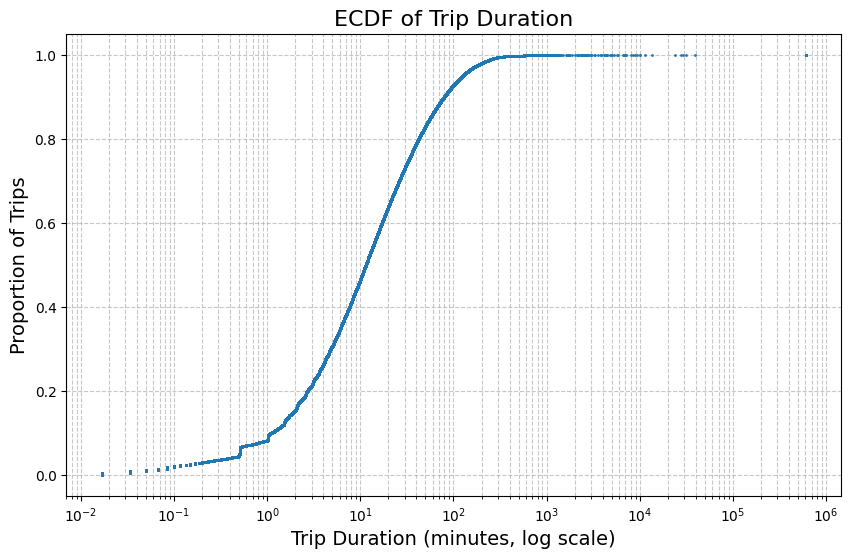

In [3]:

# Check for missing values 
data.dropna(subset=['start_time', 'stop_time'], inplace=True)

data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])


# We only want one record per trip to calculate duration correctly.
unique_trips = data.drop_duplicates(subset=['vehicle_id', 'trip_id']).copy()

# Calculate Duration (in minutes)
unique_trips['trip_duration'] = (unique_trips['stop_time'] - unique_trips['start_time']).dt.total_seconds() / 60

# Filter out zero/negative durations (essential for log scale)
unique_trips = unique_trips[unique_trips['trip_duration'] > 0]

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(10, 6))

x, y = ecdf(unique_trips['trip_duration'])

# Plotting
plt.plot(x, y, marker='.', linestyle='none', markersize=2) 

plt.title('ECDF of Trip Duration', fontsize=16)
plt.xlabel('Trip Duration (minutes, log scale)', fontsize=14)
plt.ylabel('Proportion of Trips', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Set Log Scale
plt.xscale('log')

plt.show()

/Users/thatsnegar/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


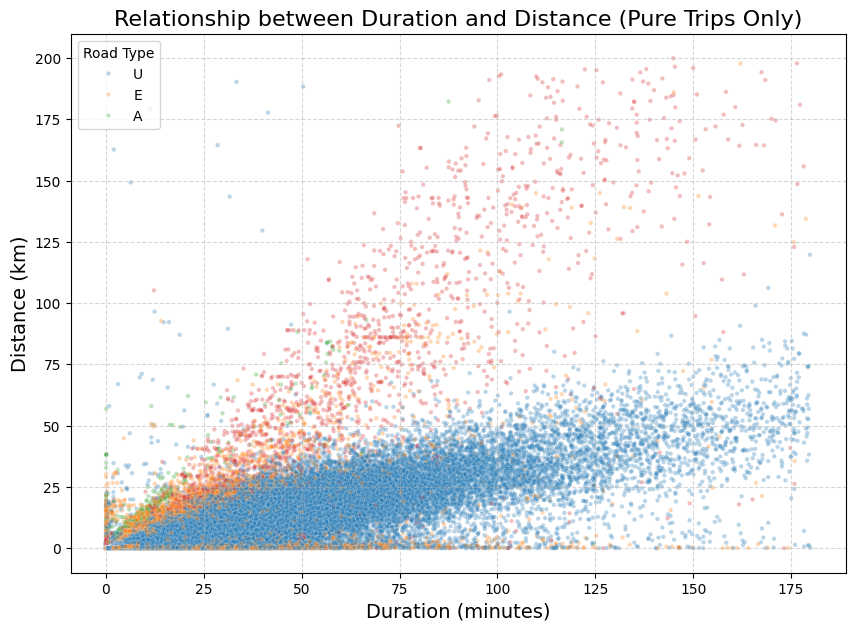

In [6]:
# Convert timestamps
data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])

# Calculate Duration
data['duration_min'] = (data['stop_time'] - data['start_time']).dt.total_seconds() / 60

# Filter for "Pure" Trips (Trips with only 1 road segment)
# We group by Trip ID and keep only groups with exactly 1 row.
# This removes "Mixed" trips (e.g., Urban + Highway) where data is misleading.
trip_counts = data.groupby(['vehicle_id', 'trip_id']).size()
pure_trip_indices = trip_counts[trip_counts == 1].index

# Select these trips from the main dataframe
pure_trips = data.set_index(['vehicle_id', 'trip_id']).loc[pure_trip_indices].reset_index()

# Filter for reasonable limits to make the plot readable (remove extreme outliers)
pure_trips = pure_trips[(pure_trips['total_distance'] < 200) & (pure_trips['duration_min'] < 180)]
pure_trips = pure_trips[pure_trips['total_distance'] > 0] # Remove 0 distance

# Plot Scatter Graph
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pure_trips, 
    x='duration_min', 
    y='total_distance', 
    hue='road', 
    alpha=0.3, 
    s=10       
)

plt.title('Relationship between Duration and Distance (Pure Trips Only)', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=14)
plt.ylabel('Distance (km)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Road Type')

plt.show()

In [11]:
data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])

data_cleaned_ = data.dropna(subset=['road', 'total_distance', 'start_time', 'stop_time']).copy()


trips_aggregated = data_cleaned_.groupby(['vehicle_id', 'trip_id']).agg({
    'start_time': 'min',         
    'stop_time': 'max',
    'total_distance': 'sum'        
}).reset_index()

# Recalculate duration on the aggregated data
trips_aggregated['trip_duration'] = (trips_aggregated['stop_time'] - trips_aggregated['start_time']).dt.total_seconds() / 60



# Define filtering criteria
min_distance = 0.1
max_distance = 1500
min_duration = 0.5
max_duration = 2500
min_speed = 1
max_speed = 200

# Filter dataset
filtered_trips = trips_aggregated[
    (trips_aggregated['total_distance'] > min_distance) &
    (trips_aggregated['total_distance'] <= max_distance) &
    (trips_aggregated['trip_duration'] > min_duration) &
    (trips_aggregated['trip_duration'] <= max_duration)
].copy()

# Calculate average speed (km/h) using TOTAL distance and TOTAL time
filtered_trips['average_speed'] = (
    filtered_trips['total_distance'] / (filtered_trips['trip_duration'] / 60)
)

# Filter based on speed
filtered_trips = filtered_trips[
    (filtered_trips['average_speed'] >= min_speed) &
    (filtered_trips['average_speed'] <= max_speed)
]

# Count valid trips
valid_trip_count = len(filtered_trips)

print("Filtering Criteria:")
print(f"1. Total distance > {min_distance} km and <= {max_distance} km")
print(f"2. Trip duration > {min_duration} minutes and <= {max_duration} minutes")
print(f"3. Average speed between {min_speed} km/h and {max_speed} km/h")
print(f"Number of valid trips: {valid_trip_count}")

Filtering Criteria:
1. Total distance > 0.1 km and <= 1500 km
2. Trip duration > 0.5 minutes and <= 2500 minutes
3. Average speed between 1 km/h and 200 km/h
Number of valid trips: 765888


**1.**  Analysing behaviours of vehicles. For each vehicle, aggregate the data on daily basis, compute following values:
- number of trips
- total distance
- utilization percetage

In [24]:
filtered_trips.head()

,vehicle_id,trip_id,start_time,stop_time,total_distance,trip_duration,average_speed
0,1,0,2023-09-29 13:55:35,2023-09-29 14:11:42,15.78,16.116667,58.746639
2,1,2,2023-09-29 15:12:03,2023-09-29 15:26:55,4.60,14.866667,18.565022
3,1,3,2023-09-29 15:37:38,2023-09-29 15:57:26,4.25,19.800000,12.878788
6,1,6,2023-09-30 05:05:39,2023-09-30 05:28:37,1.21,22.966667,3.161103
8,1,8,2023-09-30 06:07:07,2023-09-30 06:33:53,5.08,26.766667,11.387298


In [19]:
df = filtered_trips.copy() 

# Extract Date and Day Type
df['date'] = df['start_time'].dt.date
df['day_type'] = df['start_time'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Aggregate by Vehicle and Date 
daily_aggregation = df.groupby(['vehicle_id', 'date', 'day_type']).agg(
    num_trips=('trip_id', 'count'),            # Simply count the trips
    total_distance=('total_distance', 'sum'),  # Sum of distances
    total_duration_min=('trip_duration', 'sum') # Sum of durations
).reset_index()

# Calculate Utilization Percentage
# (Total Minutes Driven / Minutes in a Day) * 100
# daily_aggregation['daily_utilization'] = (daily_aggregation['total_duration_min'] / 1440)   
daily_aggregation['daily_utilization'] = daily_aggregation.groupby(['vehicle_id', 'date'])['total_duration_min'].transform('sum') / (24 * 60)  # 24 hours


# Check the results
print(daily_aggregation.head())
print(f"Max Utilization: {daily_aggregation['daily_utilization'].max():.2f}")

   vehicle_id        date day_type  num_trips  total_distance  \
0           1  2023-09-29  Weekday          3          24.630   
1           1  2023-09-30  Weekend          6          11.180   
2           1  2023-10-01  Weekend          1         361.539   
3           1  2023-10-02  Weekday          7         725.195   
4           1  2023-10-03  Weekday          8         519.620   

   total_duration_min  daily_utilization  
0           50.783333           0.035266  
1           69.066667           0.047963  
2          268.983333           0.186794  
3          562.733333           0.390787  
4          478.316667           0.332164  
Max Utilization: 1.79


In [28]:
import pandas as pd

# 1. Load and Preprocess
# We assume 'filtered_trips' contains the valid segments from your previous steps
# If starting from scratch, we ensure 'date' is created:
filtered_trips = pd.read_csv('Unipol_dataset_lab3.csv') # Or use your existing filtered_trips
filtered_trips['start_time'] = pd.to_datetime(filtered_trips['start_time'])

# --- THIS LINE FIXES YOUR ERROR ---
filtered_trips['date'] = filtered_trips['start_time'].dt.date 
# ----------------------------------

# 2. RUN THE COMPARISON

# Method A: Correct (Group by Date ONLY)
# Counts unique trip_ids per day. Even if a trip has 3 segments, it counts as 1.
daily_correct = filtered_trips.groupby(['vehicle_id', 'date']).agg(
    true_trip_count=('trip_id', 'nunique')
).reset_index()

# Method B: Inflated (Group by Road, Then Sum)
# Counts unique trip_ids per road bucket, then adds them up.
road_grouped = filtered_trips.groupby(['vehicle_id', 'date', 'road']).agg(
    road_segment_count=('trip_id', 'nunique')
).reset_index()

daily_inflated = road_grouped.groupby(['vehicle_id', 'date']).agg(
    inflated_trip_count=('road_segment_count', 'sum')
).reset_index()

# 3. Merge and Find Errors
comparison = pd.merge(daily_correct, daily_inflated, on=['vehicle_id', 'date'])
comparison['error_diff'] = comparison['inflated_trip_count'] - comparison['true_trip_count']

# Show the worst offenders
discrepancies = comparison[comparison['error_diff'] > 0].sort_values('error_diff', ascending=False)

print(f"Total Vehicle-Days Analyzed: {len(comparison)}")
print(f"Days with Double-Counting Errors: {len(discrepancies)}")
print("\n--- Top 5 Examples of the Error ---")
print(discrepancies.head(5))

# Example Breakdown for the top result
if not discrepancies.empty:
    top_row = discrepancies.iloc[0]
    vid, date = top_row['vehicle_id'], top_row['date']
    print(f"\nExample: Vehicle {vid} on {date}")
    print(f" - True Trips: {top_row['true_trip_count']}")
    print(f" - Inflated Count: {top_row['inflated_trip_count']} (Error: +{top_row['error_diff']})")

Total Vehicle-Days Analyzed: 56646
Days with Double-Counting Errors: 52503

--- Top 5 Examples of the Error ---
       vehicle_id        date  true_trip_count  inflated_trip_count  \
56325         994  2023-11-16               62                  115   
56287         994  2023-10-09               57                  110   
56284         994  2023-10-06               62                  114   
17449         307  2023-10-02               57                  107   
56289         994  2023-10-11               54                  104   

       error_diff  
56325          53  
56287          53  
56284          52  
17449          50  
56289          50  

Example: Vehicle 994 on 2023-11-16
 - True Trips: 62
 - Inflated Count: 115 (Error: +53)


- 1.a 

In [25]:

# Create 'date' and 'day_type' columns
df['date'] = df['start_time'].dt.date
df['day_type'] = df['start_time'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

#Group by Vehicle and Date ONLY 
daily_stats = df.groupby(['vehicle_id', 'date', 'day_type']).agg(
    daily_distance=('total_distance', 'sum'),
    daily_duration=('trip_duration', 'sum'),
    daily_trips=('trip_id', 'count')
).reset_index()

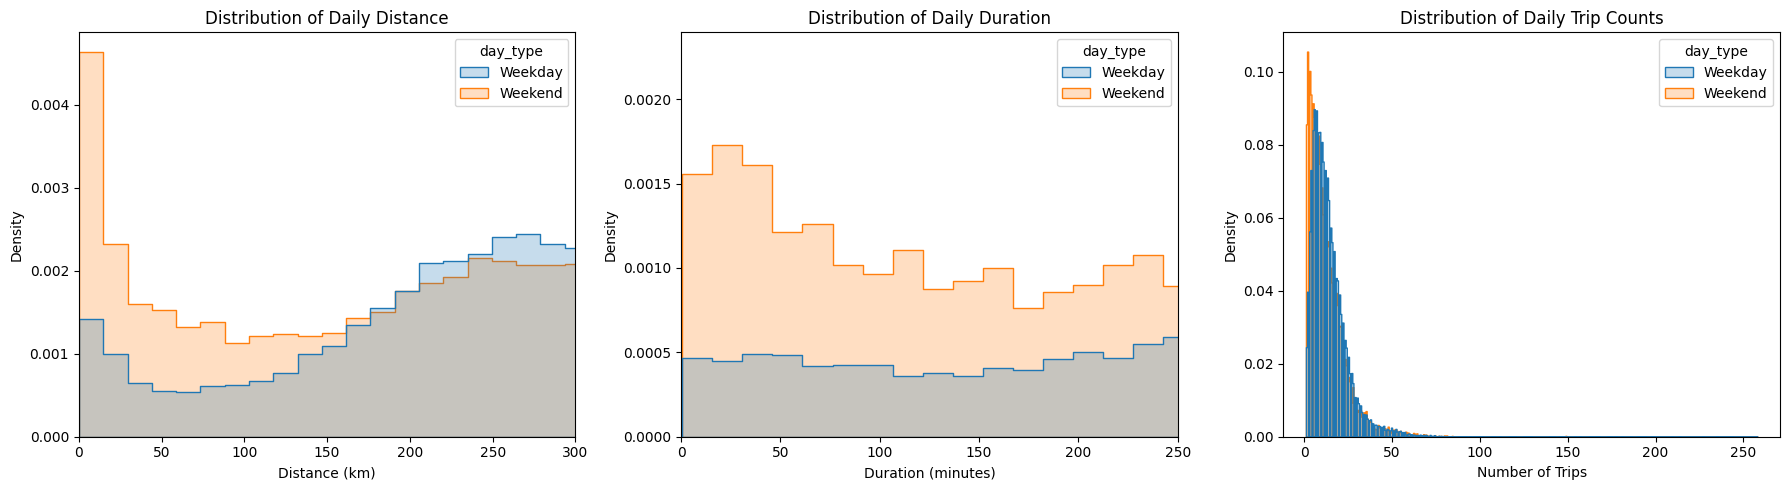

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Daily Distance
sns.histplot(data=daily_stats, x='daily_distance', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribution of Daily Distance')
axes[0].set_xlabel('Distance (km)')
axes[0].set_xlim(0, 300) 

# Plot B: Daily Duration
sns.histplot(data=daily_stats, x='daily_duration', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribution of Daily Duration')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_xlim(0, 250)

# Plot C: Number of Trips
sns.histplot(data=daily_stats, x='daily_trips', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[2])
axes[2].set_title('Distribution of Daily Trip Counts')
axes[2].set_xlabel('Number of Trips')

plt.tight_layout()
plt.show()

In [27]:
print("\n--- Statistics: Weekday vs Weekend ---")
summary_stats = daily_stats.groupby('day_type')[['daily_distance', 'daily_duration', 'daily_trips']].describe(percentiles=[0.5])
print(summary_stats.T)


# Calculate Standard Deviation of daily distance for each vehicle
vehicle_consistency = daily_stats.groupby('vehicle_id')['daily_distance'].std()

print("\n--- Top 5 Most Consistent Vehicles (Lowest Std Dev) ---")
print(vehicle_consistency.sort_values().head(5))

print("\n--- Top 5 Least Consistent Vehicles (Highest Std Dev) ---")
print(vehicle_consistency.sort_values(ascending=False).head(5))


--- Statistics: Weekday vs Weekend ---
day_type                   Weekday       Weekend
daily_distance count  41565.000000  13810.000000
               mean     398.028504    304.930555
               std      253.371526    225.804191
               min        0.110000      0.102000
               50%      339.790000    282.295000
               max     2113.040000   2046.935000
daily_duration count  41565.000000  13810.000000
               mean     531.246032    436.812172
               std      223.729155    267.925252
               min        0.533333      1.266667
               50%      541.316667    443.658333
               max     2574.600000   2509.266667
daily_trips    count  41565.000000  13810.000000
               mean      14.280284     12.478494
               std       11.690690     12.347094
               min        1.000000      1.000000
               50%       12.000000      9.000000
               max      258.000000    237.000000

--- Top 5 Most Consistent Ve